In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

===== 0 mM IMP =====
F0  = 0.0000 ± 0.0819
Bmax = 2419586.5705 ± 574.1840
K d  = 65140172.0846 mM ± 21327662.4317

===== 1 mM IMP =====
F0  = 0.0000 ± 0.3298
Bmax = 1.8958 ± 1.5454
K d  = 12.0332 mM ± 24.2226


Text(0.5, 0, 'Ligand (mM)')

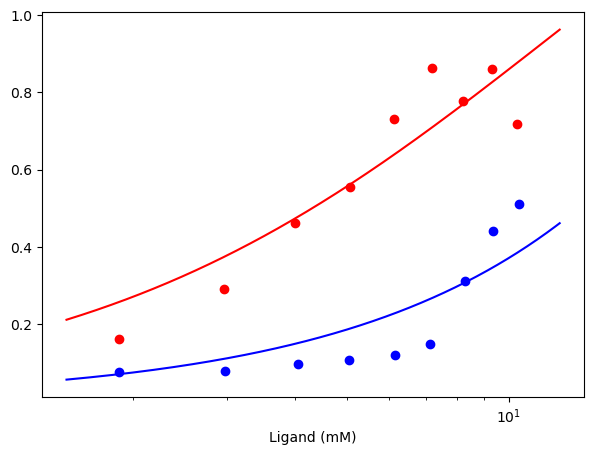

In [4]:


def binding_with_baseline(L, F0, Bmax, Kd):
    return F0 + (Bmax * L) / (Kd + L)

# Fit 0 M IMP
p0_0 = [Y0.min(), Y0.max() - Y0.min(), np.median(L0)]
bounds = ([0, 0, 0], [1.0, np.inf, np.inf])  # F0 ≤ 1.0 is safe
params0, cov0 = curve_fit(binding_with_baseline, L0, Y0,
                          p0=p0_0, bounds=bounds)

F0_0, Bmax_0, Kd_0 = params0
err0 = np.sqrt(np.diag(cov0))

# Fit 1 mM IMP
p0_1 = [Y1.min(), Y1.max() - Y1.min(), np.median(L1)]
params1, cov1 = curve_fit(binding_with_baseline, L1, Y1,
                          p0=p0_1, bounds=bounds)

F0_1, Bmax_1, Kd_1 = params1
err1 = np.sqrt(np.diag(cov1))

print("===== 0 mM IMP =====")
print(f"F0  = {F0_0:.4f} ± {err0[0]:.4f}")
print(f"Bmax = {Bmax_0:.4f} ± {err0[1]:.4f}")
print(f"K d  = {Kd_0*1000:.4f} mM ± {err0[2]*1000:.4f}")

print("\n===== 1 mM IMP =====")
print(f"F0  = {F0_1:.4f} ± {err1[0]:.4f}")
print(f"Bmax = {Bmax_1:.4f} ± {err1[1]:.4f}")
print(f"K d  = {Kd_1*1000:.4f} mM ± {err1[2]*1000:.4f}")

# Plot
Lplot = np.logspace(np.log10(min(L0)*0.8), np.log10(max(L1)*1.2), 500)

plt.figure(figsize=(7,5))
plt.scatter(L0*1000, Y0, label="0 mM IMP", color="blue")
plt.plot(Lplot*1000, binding_isotherm(Lplot, Bmax0, Kd0), color="blue")

plt.scatter(L1*1000, Y1, label="1 mM IMP", color="red")
plt.plot(Lplot*1000, binding_isotherm(Lplot, Bmax1, Kd1), color="red")

plt.xscale('log')
plt.xlabel("Ligand (mM)")


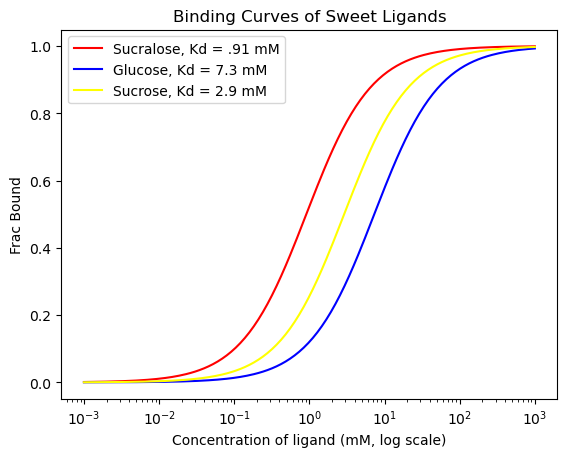

In [10]:
def eq(kd, x):
    return x / (kd + x)

kd_sucralose = .91
kd_glucose = 7.3
kd_sucrose = 2.9

x = np.logspace(-3, 3, 200)


#plt.rcParams["font.family"] = "Times New Roman"
plt.semilogx(x, eq(kd_sucralose, x), label='Sucralose, Kd = .91 mM', color = 'Red')
plt.semilogx(x, eq(kd_glucose, x), label='Glucose, Kd = 7.3 mM', color = 'Blue')
plt.semilogx(x, eq(kd_sucrose, x), label='Sucrose, Kd = 2.9 mM', color = 'Yellow')
plt.xlabel("Concentration of ligand (mM, log scale)")
plt.ylabel("Frac Bound")
plt.title("Binding Curves of Sweet Ligands")
plt.legend()

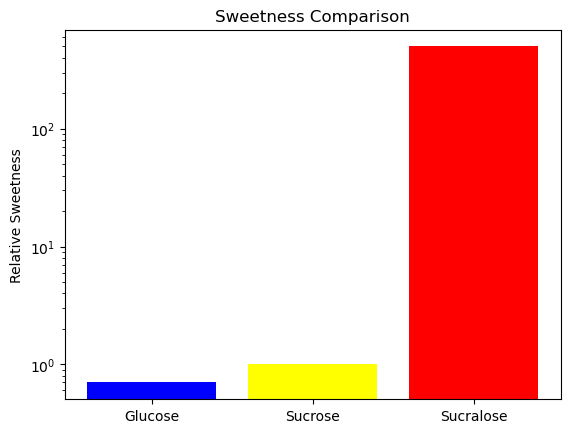

In [11]:
import matplotlib.pyplot as plt

# Relative sweetness
sweetness = [0.7, 1.0, 500]  # approximate
ligands = ['Glucose', 'Sucrose', 'Sucralose']

plt.bar(ligands, sweetness, color=['Blue', 'Yellow', 'Red'])
plt.ylabel('Relative Sweetness')
plt.title('Sweetness Comparison')
plt.yscale('log') 
plt.show()


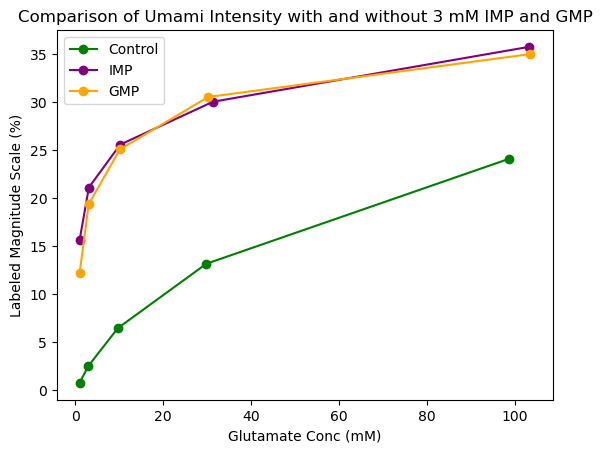

In [9]:
import pandas as pd

df_control = pd.read_csv("control.csv", header=None)
df_IMP = pd.read_csv("IMP.csv", header=None)
df_GMP = pd.read_csv("GMP.csv", header=None)

X_control = df_control.iloc[:, [0]]
y_control = df_control.iloc[:, 1] 

X_IMP = df_IMP.iloc[:, [0]]
y_IMP = df_IMP.iloc[:, 1] 

X_GMP = df_GMP.iloc[:, [0]]
y_GMP = df_GMP.iloc[:, 1] 


plt.plot(X_control, y_control, marker='o', label='Control', color='Green')
plt.plot(X_IMP, y_IMP,  marker='o', label='IMP', color='Purple')
plt.plot(X_GMP, y_GMP,  marker='o', label='GMP', color='Orange')

plt.xlabel("Glutamate Conc (mM)")
plt.ylabel("Labeled Magnitude Scale (%)")
plt.title("Comparison of Umami Intensity with and without 3 mM IMP and GMP")
plt.legend()